# Exploratory Data Analysis (EDA) — Customer, Account & Behaviour Analysis

## Objective

This notebook performs Exploratory Data Analysis (EDA) on the cleaned **customer**, **account**, **card**, and **transaction** datasets from the banking analytics project.

The objective is to understand who the bank's customers are, how their accounts are structured, and how they interact with the bank's financial products and services. The analysis explores customer demographics, financial health, account characteristics, card preferences, and transaction behaviour to identify meaningful business patterns and customer segments.

The cleaned datasets prepared during the Data Cleaning phase are used throughout this notebook.

> **Note:** Detailed Transaction Analysis and Branch, Merchant, Complaint & Loan Analysis are covered in separate notebooks.

---

## Business Questions Covered in This Notebook

### Customer Analysis

* What is the gender distribution of customers?
* What is the age distribution of customers?
* Which occupations are most common among customers?
* How is customer income distributed?
* How are customer credit scores distributed?
* How are customers distributed across risk categories?
* Which customer segments have the highest number of customers?

### Account Analysis

* Which account types are most commonly held?
* How are current account balances distributed?
* How are average monthly balances distributed across accounts?
* Which branches manage the highest number of accounts?
* What is the average account balance by customer segment?

### Customer Behaviour Analysis

* Which card types are issued most frequently?
* How do card preferences vary across customer segments?
* How does average transaction amount differ across customer segments?
* What relationships exist between age, monthly income, and credit score?

---

## Expected Outcome

By the end of this notebook, comprehensive insights will be generated into customer demographics, financial health, account characteristics, and customer behaviour. These findings provide a strong foundation for understanding customer value, product usage, and financial patterns, while also supporting the development of interactive Tableau dashboards and subsequent transaction, operational, and loan analyses in later phases of the project.


## Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

pd.set_option("display.max_columns", None)

plt.style.use("ggplot")

## Loading the Cleaned Datasets



In [30]:
customers = pd.read_csv("data/Cleaned/dim_customers.csv")
accounts = pd.read_csv("data/Cleaned/dim_accounts.csv")
cards= pd.read_csv("data/Cleaned/dim_cards.csv")
branches = pd.read_csv("data/Cleaned/dim_branches.csv")
merchants = pd.read_csv("data/Cleaned/dim_merchants.csv")
dates = pd.read_csv("data/Cleaned/dim_date.csv")
transactions = pd.read_csv("data/Cleaned/fact_transactions.csv")
loans = pd.read_csv("data/Cleaned/fact_loans.csv")
complaints = pd.read_csv("data/Cleaned/fact_complaints.csv")

## Dataset Overview

Before starting the analysis, the size of each dataset is checked to confirm all files loaded correctly.

In [31]:
datasets = {
    "Customers": customers,
    "Accounts": accounts,
    "Cards": cards,
    "Branches": branches,
    "Merchants" : merchants,
    "Date": dates,
    "Transactions": transactions,
    "Loans": loans,
    "Complaints": complaints
}

overview = pd.DataFrame({
    "Table"  : datasets.keys(),
    "Rows"   : [df.shape[0] for df in datasets.values()],
    "Columns": [df.shape[1] for df in datasets.values()]
})

overview

,Table,Rows,Columns
0,Customers,150000,23
1,Accounts,240000,10
2,Cards,300000,7
3,Branches,25,12
4,Merchants,3500,5
5,Date,1096,13
6,Transactions,2497795,13
7,Loans,120000,12
8,Complaints,11124,10


---

# Data Preparation for Analysis

Before performing exploratory data analysis, the required datasets are merged to create analysis-ready tables. These merged datasets combine customer, account, card, and transaction information, enabling customer-level behavioural and financial analysis throughout this notebook.

The following merged datasets are created:

- **Customer + Account:** Used for account balance and account-related analysis.
- **Customer + Account + Card:** Used to analyze card ownership and customer preferences.
- **Customer + Transaction:** Used to calculate average transaction amount for each customer and support customer behaviour analysis.

---

In [32]:
# Merge customer and account data for account balance analysis
cust_acc = customers.merge(accounts, on='customer_id', how='left')

# Merge customer, account, and card data for card behaviour analysis
cust_cards = (
    customers
    .merge(accounts[['customer_id', 'account_id']], on='customer_id', how='left')
    .merge(cards, on='account_id', how='left')
)

# Add customer_id to transactions through accounts
txn = transactions.merge(
    accounts[['account_id', 'customer_id']],
    on='account_id',
    how='left'
)

# Calculate average transaction amount per customer
cust_txn = (
    txn.groupby('customer_id', as_index=False)['amount']
       .mean()
       .rename(columns={'amount': 'avg_transaction'})
)

cust_txn = customers.merge(cust_txn, on='customer_id', how='left')

## Preview of the Key Datasets

A quick look at the first few rows of the customer and account data confirms the structure before analysis begins.

In [33]:
customers.head()

,customer_id,name,age,gender,occupation,employment_type,education,marital_status,income_bracket,monthly_income,credit_score,risk_category,customer_segment,kyc_status,signup_date,city,state,home_branch_id,is_digital_banking_user,is_upi_user,is_mobile_app_user,sms_alerts_enabled,is_insurance_holder
0,CUST000001,Robert Garcia,18,Female,Student,Part-Time,Bachelor's,Divorced,Low,21373,523,High Risk,New,Verified,2024-12-03,Hyderabad,Telangana,BR0007,True,True,False,True,False
1,CUST000002,Janice Petty,65,Female,Salaried - Private,Part-Time,Diploma,Married,Upper-Middle,145501,834,Low Risk,Premium,Pending,2022-09-27,Hyderabad,Telangana,BR0007,True,False,True,False,True
2,CUST000003,Victor Waller,33,Male,Self-Employed,Contract,Bachelor's,Married,Upper-Middle,145831,828,Low Risk,Premium,Verified,2022-02-11,Chandigarh,Punjab,BR0002,True,True,True,True,False
3,CUST000004,Brenda Morrison,40,Male,Student,Self-Employed,Master's,Married,Lower-Middle,28208,669,Medium Risk,Regular,Verified,2023-11-08,Patna,Bihar,BR0014,True,False,True,True,True
4,CUST000005,Michael Valencia,21,Male,Salaried - Private,Self-Employed,Bachelor's,Single,Upper-Middle,125489,805,Low Risk,Premium,Verified,2024-05-11,Surat,Gujarat,BR0012,True,True,False,False,False


In [34]:
accounts.head()

,account_id,customer_id,account_type,open_date,branch_id,status,current_balance,avg_monthly_balance,min_balance,interest_earned
0,ACC000001,CUST000001,Savings,2024-12-28,BR0007,Closed,7043.48,9744.78,3059.79,337.77
1,ACC000002,CUST000002,Savings,2024-01-14,BR0007,Active,106054.45,107553.31,30272.52,3364.24
2,ACC000003,CUST000003,Current,2024-04-27,BR0002,Active,153213.97,156886.06,31782.60,868.57
3,ACC000004,CUST000004,Credit,2024-01-14,BR0014,Active,13301.96,15027.49,2231.49,0.00
4,ACC000005,CUST000005,Savings,2024-07-07,BR0012,Active,147344.43,138577.87,45921.54,4569.67


### Observation

- All nine datasets loaded successfully with the expected number of rows and columns.
- The `customers` dataset contains demographic fields such as age, gender, occupation, income, credit score, risk category, and customer segment.
- The `accounts` dataset contains account type, current balance, average monthly balance, and branch information linked by `customer_id` and `branch_id`.
- These two datasets form the foundation for all analysis in this notebook.

---

# Section 1: Customer Analysis

This section explores the bank's customer base — who they are, what they earn, their credit health, and how they are segmented.

Understanding customer demographics helps the bank tailor its products, manage risk, and plan marketing strategies.

## Question 1: What is the gender distribution of customers?

In [35]:
# Count customers by gender
gender_counts = customers["gender"].value_counts()
print(gender_counts)

gender
Male       75146
Female     71854
Unknown     3000
Name: count, dtype: int64


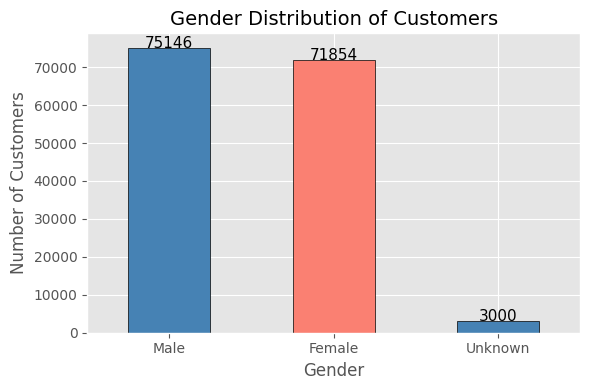

In [36]:
# Bar chart — Gender Distribution
gender_counts.plot(
    kind="bar",
    figsize=(6, 4),
    color=["steelblue", "salmon"],
    edgecolor="black"
)

plt.title("Gender Distribution of Customers", fontsize=14)
plt.xlabel("Gender", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)
plt.xticks(rotation=0)

# Add count labels on top of each bar
for i, v in enumerate(gender_counts):
    plt.text(i, v + 5, str(v), ha="center", fontsize=11)

plt.tight_layout()
plt.show()

### Observation

- Male customers slightly outnumber female customers, but the difference is small.
- The gender split is broadly balanced, which means the bank is not serving a heavily skewed customer base.
- **Business Implication:** A near-equal gender distribution allows the bank to design products and campaigns that are relevant to both groups equally, rather than heavily favouring one segment.

## Question 2: What is the age distribution of customers?

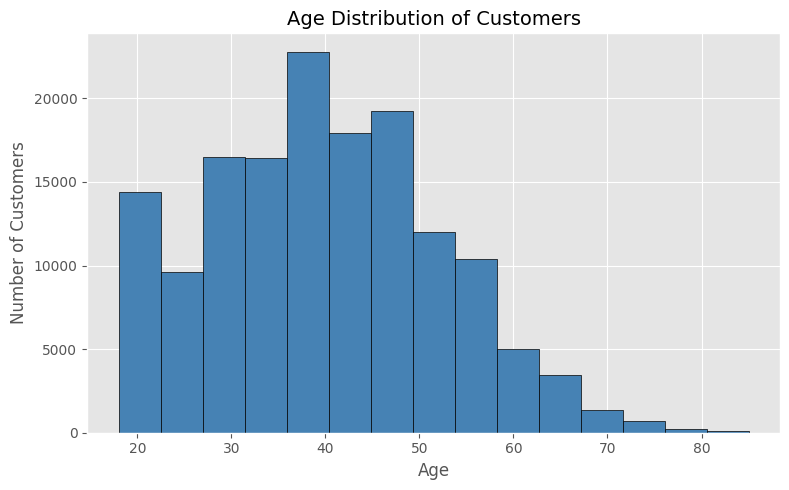

In [37]:
# Histogram — Age Distribution
plt.figure(figsize=(8, 5))

plt.hist(customers["age"], bins=15, color="steelblue", edgecolor="black")

plt.title("Age Distribution of Customers", fontsize=14)
plt.xlabel("Age", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)

plt.tight_layout()
plt.show()

### Observation

- The age distribution is spread across a wide range, indicating the bank serves customers from early adulthood through retirement.
- The largest concentration of customers falls in the working-age group (roughly 25–50 years), which is typical for a retail bank.
- There are relatively fewer very young customers (under 25) and older customers (above 60).
- **Business Implication:** The bank's core customer base is working-age adults. Products like home loans, car loans, and savings accounts are likely to be in highest demand from this age group.

## Question 3: Which occupations are most common among customers?

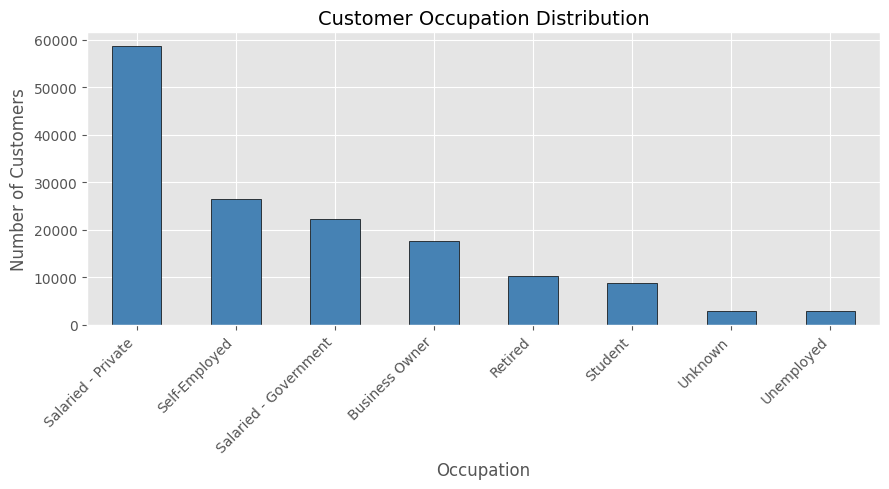

In [38]:
# Bar chart — Occupation Distribution
customers["occupation"].value_counts().plot(
    kind="bar",
    figsize=(9, 5),
    color="steelblue",
    edgecolor="black"
)

plt.title("Customer Occupation Distribution", fontsize=14)
plt.xlabel("Occupation", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

### Observation

- Salaried employees and private sector workers form the largest portion of the customer base.
- Self-employed customers and business owners are also well-represented.
- Students and retired individuals make up the smaller segments of the customer base.
- **Business Implication:** Because salaried customers dominate, payroll services, salary accounts, and personal loans are likely the bank's most important products. Retired customers, while fewer, may benefit from fixed deposits and pension-linked products.

## Question 4: How is customer monthly income distributed?

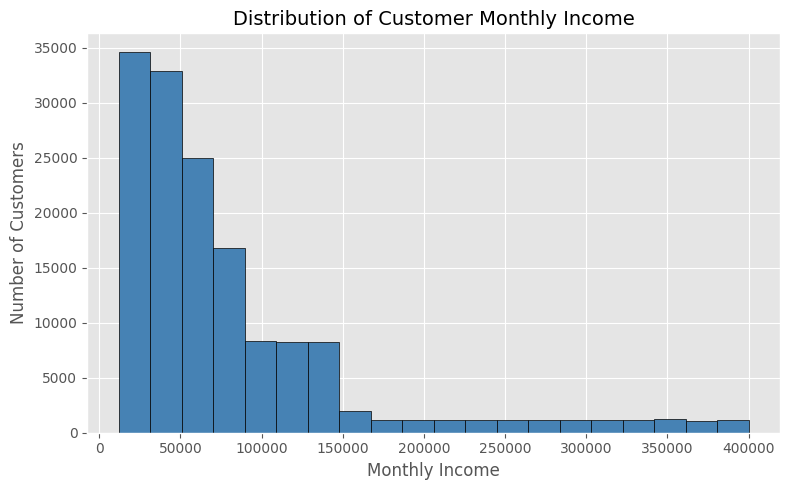

In [39]:
# Histogram — Monthly Income Distribution
plt.figure(figsize=(8, 5))

plt.hist(customers["monthly_income"], bins=20, color="steelblue", edgecolor="black")

plt.title("Distribution of Customer Monthly Income", fontsize=14)
plt.xlabel("Monthly Income", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)

plt.tight_layout()
plt.show()

### Observation

- Monthly income is right-skewed — the majority of customers earn in the lower to middle income range, while a small number of customers earn significantly higher incomes.
- This pattern is typical of a retail banking customer base.
- **Business Implication:** The bank should ensure its core product offerings (basic savings accounts, personal loans, low-fee credit cards) are accessible and relevant to the lower and middle income majority. Premium products can be targeted at the smaller high-income segment.

## Question 5: How are customer credit scores distributed?

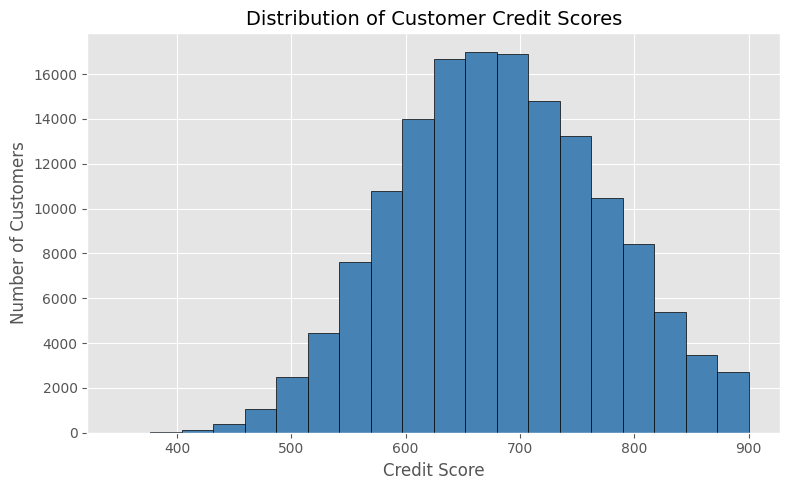

In [40]:
# Histogram — Credit Score Distribution
plt.figure(figsize=(8, 5))

plt.hist(customers["credit_score"], bins=20, color="steelblue", edgecolor="black")

plt.title("Distribution of Customer Credit Scores", fontsize=14)
plt.xlabel("Credit Score", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)

plt.tight_layout()
plt.show()

### Observation

- Credit scores are spread across a wide range, covering low, medium, and high creditworthiness groups.
- No single score range appears to dominate heavily, indicating a diverse customer base in terms of financial reliability.
- **Business Implication:** A broad credit score spread means the bank carries customers at different risk levels. Customers with lower credit scores may be candidates for financial literacy programmes or secured loan products, while high-score customers are good candidates for premium credit and loan offerings.

## Question 6: How are customers distributed across risk categories?

In [41]:
# Count customers by risk category
risk_counts = customers["risk_category"].value_counts()
print(risk_counts)

risk_category
Low Risk       63267
Medium Risk    58451
High Risk      28282
Name: count, dtype: int64


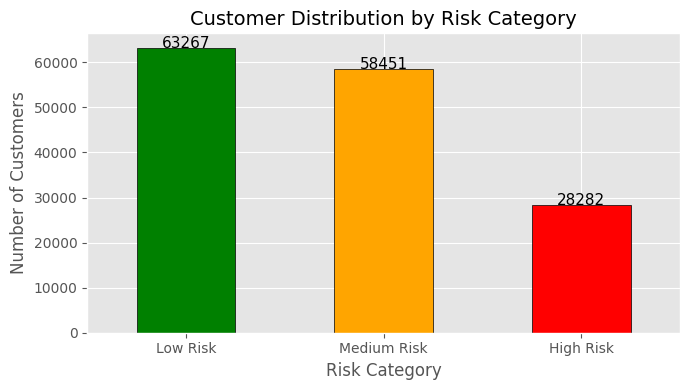

In [42]:
# Bar chart — Risk Category Distribution
risk_counts.plot(
    kind="bar",
    figsize=(7, 4),
    color=["green", "orange", "red"],
    edgecolor="black"
)

plt.title("Customer Distribution by Risk Category", fontsize=14)
plt.xlabel("Risk Category", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)
plt.xticks(rotation=0)

# Add count labels
for i, v in enumerate(risk_counts):
    plt.text(i, v + 5, str(v), ha="center", fontsize=11)

plt.tight_layout()
plt.show()

### Observation

- The majority of customers fall into the Low or Medium risk categories, which indicates a generally healthy customer base.
- A meaningful portion of customers are classified as High Risk, representing a segment requiring closer monitoring.
- **Business Implication:** Low and medium risk customers can be offered standard lending products. High-risk customers should be subject to stricter credit checks and may be better suited for secured products. Monitoring this risk distribution over time helps the bank manage its overall credit exposure.

## Question 7: Which customer segments have the highest number of customers?

In [43]:
# Count customers by segment
segment_counts = customers["customer_segment"].value_counts()
print(segment_counts)

customer_segment
Regular    62842
Loyal      45134
Premium    31439
New        10585
Name: count, dtype: int64


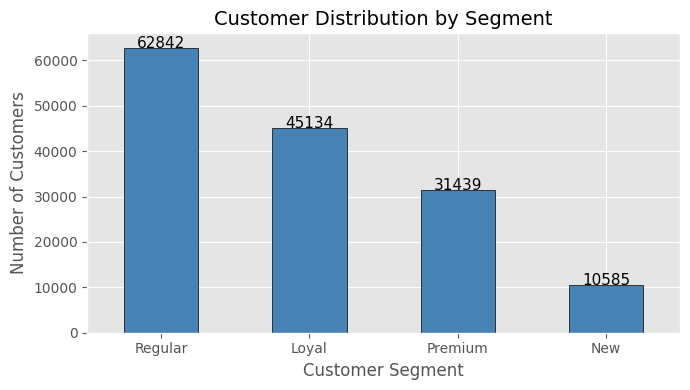

In [44]:
# Bar chart — Customer Segment Distribution
segment_counts.plot(
    kind="bar",
    figsize=(7, 4),
    color="steelblue",
    edgecolor="black"
)

plt.title("Customer Distribution by Segment", fontsize=14)
plt.xlabel("Customer Segment", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)
plt.xticks(rotation=0)

# Add count labels
for i, v in enumerate(segment_counts):
    plt.text(i, v + 5, str(v), ha="center", fontsize=11)

plt.tight_layout()
plt.show()

### Observation

- The customer base is divided across multiple segments such as Mass, Regular, and Premium (or similar, depending on the data).
- The largest segment represents the bank's primary customer group and drives the most volume of everyday banking activity.
- Smaller segments like Premium customers, though fewer in number, often contribute disproportionately to revenue through higher-value products.
- **Business Implication:** The bank should ensure its products and service quality are calibrated for each segment. Mass customers need affordable, accessible products. Premium customers need relationship banking and personalised service.

---

# Section 2: Account Analysis

This section examines the accounts held by customers — what types of accounts they have, how much money they hold, and which branches manage the most accounts.

Account data, when combined with customer data, reveals how different customer groups use the bank.

## Question 8: Which account types are most commonly held?

In [45]:
# Count accounts by type
account_type_counts = accounts["account_type"].value_counts()
print(account_type_counts)

account_type
Savings    120011
Current     83958
Credit      36031
Name: count, dtype: int64


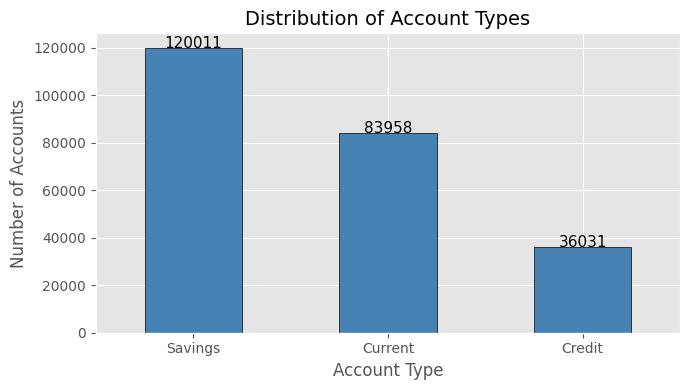

In [46]:
# Bar chart — Account Type Distribution
account_type_counts.plot(
    kind="bar",
    figsize=(7, 4),
    color="steelblue",
    edgecolor="black"
)

plt.title("Distribution of Account Types", fontsize=14)
plt.xlabel("Account Type", fontsize=12)
plt.ylabel("Number of Accounts", fontsize=12)
plt.xticks(rotation=0)

# Add count labels
for i, v in enumerate(account_type_counts):
    plt.text(i, v + 5, str(v), ha="center", fontsize=11)

plt.tight_layout()
plt.show()

### Observation

- Savings accounts are the most common account type, followed by current accounts and other types.
- This is expected for a retail bank — savings accounts are the most basic and widely used banking product.
- **Business Implication:** Because savings accounts dominate, the bank's ability to attract and retain savings balances is critical. Offering competitive interest rates on savings accounts helps grow the deposit base, which supports the bank's lending capacity.

## Question 9 & 10: How are current balances and average monthly balances distributed?

These two balance columns are compared together to see whether customers maintain consistent balances over time.

In [47]:
# Summary statistics for both balance columns
print("--- Current Balance ---")
print(accounts["current_balance"].describe())
print()
print("--- Average Monthly Balance ---")
print(accounts["avg_monthly_balance"].describe())

--- Current Balance ---
count    2.400000e+05
mean     8.976686e+04
std      1.384892e+05
min      6.397000e+02
25%      1.882341e+04
50%      3.791629e+04
75%      9.823877e+04
max      2.582593e+06
Name: current_balance, dtype: float64

--- Average Monthly Balance ---
count    2.400000e+05
mean     8.972760e+04
std      1.357873e+05
min      8.024800e+02
25%      1.927348e+04
50%      3.820945e+04
75%      9.960335e+04
max      2.809771e+06
Name: avg_monthly_balance, dtype: float64


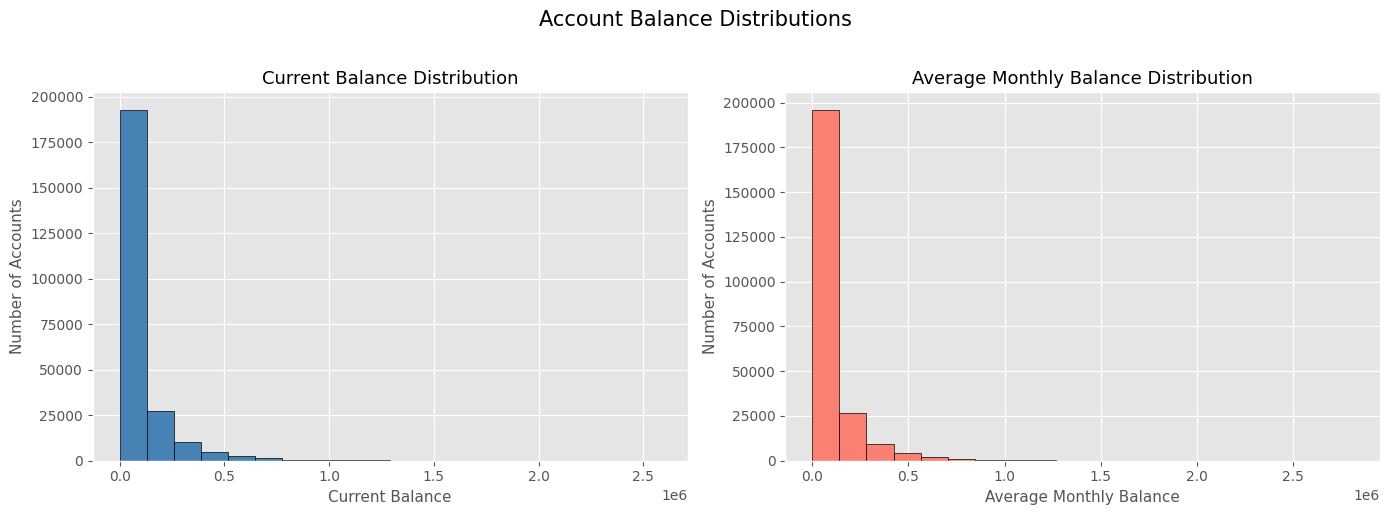

In [48]:
# Side-by-side histograms — Current Balance vs Average Monthly Balance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(accounts["current_balance"], bins=20, color="steelblue", edgecolor="black")
axes[0].set_title("Current Balance Distribution", fontsize=13)
axes[0].set_xlabel("Current Balance", fontsize=11)
axes[0].set_ylabel("Number of Accounts", fontsize=11)

axes[1].hist(accounts["avg_monthly_balance"], bins=20, color="salmon", edgecolor="black")
axes[1].set_title("Average Monthly Balance Distribution", fontsize=13)
axes[1].set_xlabel("Average Monthly Balance", fontsize=11)
axes[1].set_ylabel("Number of Accounts", fontsize=11)

plt.suptitle("Account Balance Distributions", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

### Observation

- Both the current balance and average monthly balance distributions follow a similar right-skewed pattern — most accounts carry lower balances, while a smaller number of accounts hold significantly higher amounts.
- The two distributions are broadly similar in shape, which suggests that customers who maintain high balances tend to do so consistently over time.
- **Business Implication:** The concentration of accounts in the lower balance range means that a small group of high-balance customers contributes a large portion of the bank's deposit base. Retaining these high-balance customers through loyalty programmes or premium services should be a priority.

## Question 11: Which branches manage the highest number of accounts?

In [49]:
# Get top 10 branches by account count and join branch names
branch_counts = accounts["branch_id"].value_counts().reset_index()
branch_counts.columns = ["branch_id", "num_accounts"]

# Join branch name from branches dataframe
branch_counts = branch_counts.merge(
    branches[["branch_id", "branch_name"]],
    on="branch_id",
    how="left"
)

# Display top 10
top10_branches = branch_counts.head(10)
print(top10_branches[["branch_name", "num_accounts"]])

          branch_name  num_accounts
0      Kochi Branch 2         20454
1  Hyderabad Branch 1         20186
2    Kolkata Branch 1         19086
3     Jaipur Branch 1         17534
4       Pune Branch 1         12946
5    Lucknow Branch 1         11719
6    Lucknow Branch 2         11166
7   Guwahati Branch 1         10533
8    Chennai Branch 1         10105
9  Bangalore Branch 1          9835


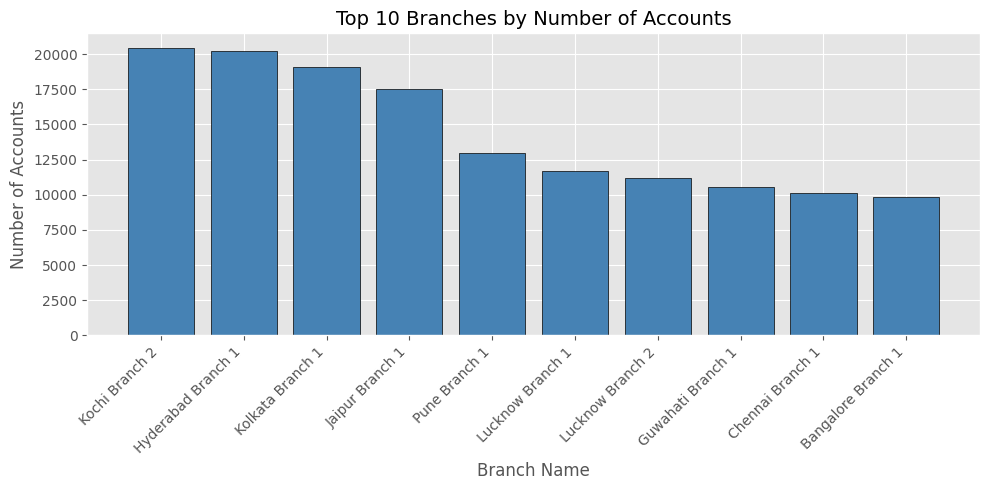

In [50]:
# Bar chart — Top 10 Branches by Number of Accounts
plt.figure(figsize=(10, 5))

plt.bar(top10_branches["branch_name"], top10_branches["num_accounts"],
        color="steelblue", edgecolor="black")

plt.title("Top 10 Branches by Number of Accounts", fontsize=14)
plt.xlabel("Branch Name", fontsize=12)
plt.ylabel("Number of Accounts", fontsize=12)
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

### Observation

- A small number of branches manage a disproportionately large share of customer accounts, indicating high customer concentration in those locations.
- These top branches are likely located in high-footfall areas such as city centres or commercial districts.
- **Business Implication:** Branches with the highest account volumes are critical to the bank's operations. Ensuring adequate staffing, infrastructure, and service quality at these branches directly impacts a large portion of the customer base. Lower-activity branches may be candidates for digitalisation or restructuring.

## Question 12: What is the average account balance for each customer segment?

This question joins the `customers` and `accounts` datasets to connect customer segment information with account balance data.
This is the first cross-dataset question in this notebook.

In [51]:
# Join customers and accounts on customer_id
customer_accounts = accounts.merge(
    customers[["customer_id", "customer_segment"]],
    on="customer_id",
    how="left"
)

# Calculate average current balance per customer segment
avg_balance_by_segment = (
    customer_accounts
    .groupby("customer_segment")["current_balance"]
    .mean()
    .sort_values(ascending=False)
    .round(2)
)

print(avg_balance_by_segment)

customer_segment
Premium    251247.72
Loyal       76877.06
Regular     29387.63
New         22145.61
Name: current_balance, dtype: float64


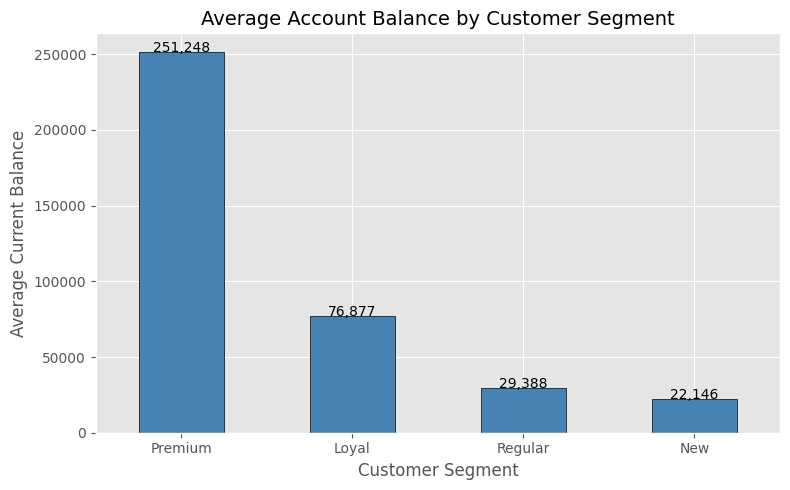

In [52]:
# Bar chart — Average Balance by Customer Segment
avg_balance_by_segment.plot(
    kind="bar",
    figsize=(8, 5),
    color="steelblue",
    edgecolor="black"
)

plt.title("Average Account Balance by Customer Segment", fontsize=14)
plt.xlabel("Customer Segment", fontsize=12)
plt.ylabel("Average Current Balance", fontsize=12)
plt.xticks(rotation=0)

# Add value labels on top of each bar
for i, v in enumerate(avg_balance_by_segment):
    plt.text(i, v + 50, f"{v:,.0f}", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

### Observation

- Premium customers hold the highest average account balances, followed by Regular and Mass customers — which is the expected pattern for a segmented customer base.
- The gap between segments confirms that customer segments are meaningfully differentiated not just by label, but by actual financial behaviour.
- **Business Implication:** This validates the bank's segmentation model. Premium customers with high balances represent high-value relationships and should receive dedicated relationship management. Mass customers, while lower in average balance, are the most numerous and represent the bank's broadest revenue opportunity through volume.

# Section 3: Customer Behaviour Analysis

This section analyzes how customers interact with the bank's products and services by examining card preferences, transaction spending patterns, and relationships between key financial indicators.

Understanding customer behaviour helps the bank identify product preferences, evaluate customer value, personalize financial offerings, and support data-driven business decisions for customer engagement and retention.

## Question 1. Card Distribution by Card Type

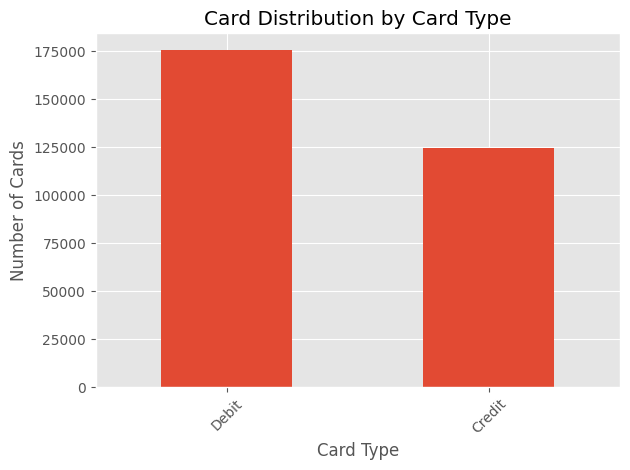

In [53]:
cards['card_type'].value_counts().plot(kind='bar')
plt.title('Card Distribution by Card Type')
plt.xlabel('Card Type')
plt.ylabel('Number of Cards')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Observation

Standard cards account for the largest share of issued cards, while premium variants serve a smaller customer group. Eligible customers could be encouraged to upgrade through targeted promotional campaigns.

## Question 2. Card Type by Customer Segment

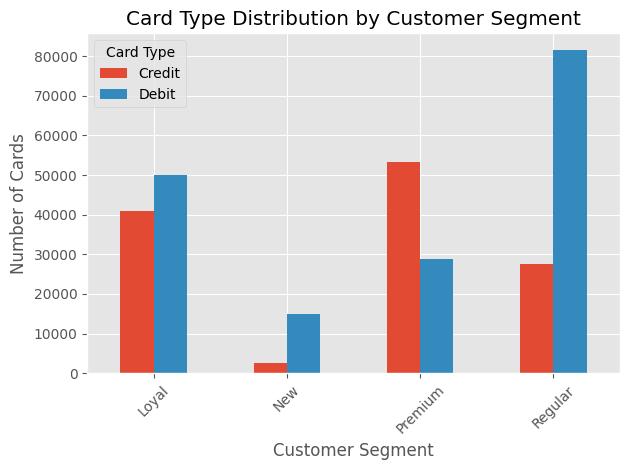

In [54]:
cust_cards.groupby(['customer_segment', 'card_type']).size().unstack().plot(kind='bar')
plt.title('Card Type Distribution by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Cards')
plt.xticks(rotation=45)
plt.legend(title='Card Type')
plt.tight_layout()
plt.show()

### Observation

Card ownership closely follows customer segmentation, indicating that premium products are generally reaching the intended audience. A small portion of Standard customers may also qualify for premium card upgrades.

## Question 3. Average Transaction Amount by Customer Segment

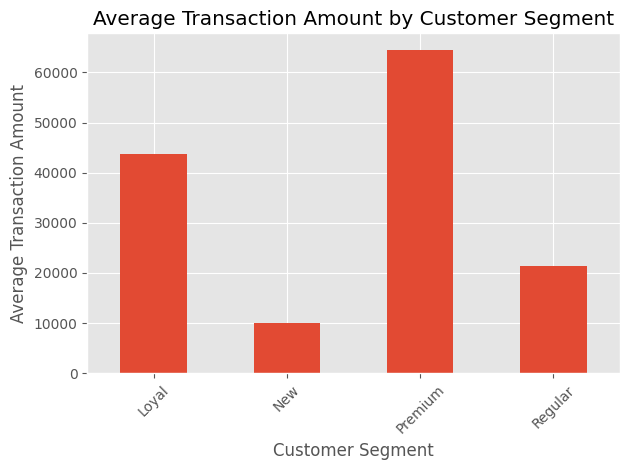

In [55]:
cust_txn.groupby('customer_segment')['avg_transaction'].mean().plot(kind='bar')
plt.title('Average Transaction Amount by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Average Transaction Amount')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Observation

Premium customers spend more on average per transaction, reinforcing their higher lifetime value. Retaining these customers and increasing engagement can positively influence transaction-based revenue.

## Question 4. Correlation Heatmap – Age, Monthly Income, Credit Score

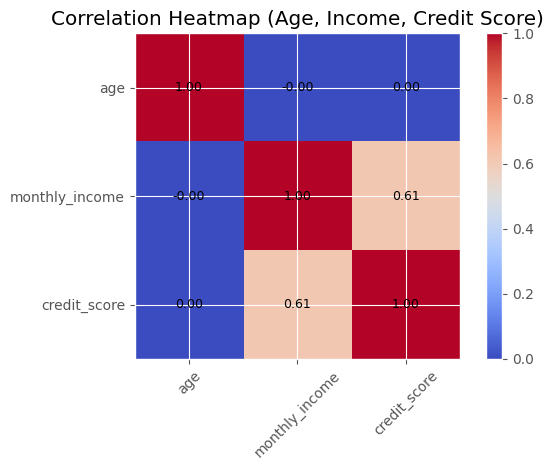

In [56]:
import numpy as np

corr = customers[['age', 'monthly_income', 'credit_score']].corr()

fig, ax = plt.subplots()
im = ax.imshow(corr, cmap='coolwarm')
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45)
ax.set_yticklabels(corr.columns)
plt.colorbar(im)

# Add value annotations
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}",
                ha='center', va='center', color='black', fontsize=9)

plt.title('Correlation Heatmap (Age, Income, Credit Score)')
plt.tight_layout()
plt.show()

### Observation

Monthly income shows the strongest positive relationship with credit score among the selected variables, while age has only a weak association. Overall, the correlations are modest, indicating that customer behaviour is driven by multiple factors.

---

# Summary of Key Findings

## Customer Analysis

| Finding | Detail |
|---|---|
| Gender | Near-equal gender split; male customers slightly higher |
| Age | Most customers are working-age adults (25–50 years) |
| Occupation | Salaried and private sector employees dominate |
| Income | Right-skewed; most customers are in the lower to middle income range |
| Credit Score | Spread across low, medium, and high ranges |
| Risk Category | Majority are low or medium risk; some high-risk customers present |
| Customer Segment | Largest segment is Mass/Regular; Premium customers are fewer but valuable |

## Account Analysis

| Finding | Detail |
|---|---|
| Account Type | Savings accounts are the most common |
| Current Balance | Right-skewed; most accounts hold lower balances |
| Monthly Balance | Mirrors current balance pattern, indicating stable account activity over time |
| Branch Activity | A few high-activity branches manage a large share of customer accounts |
| Balance by Segment | Premium customers maintain significantly higher average account balances |

## Customer Behaviour Analysis

| Finding | Detail |
|---|---|
| Card Type | Debit cards are the most widely issued, while premium card types are less common |
| Card Preference | Premium customer segments are more likely to own premium card types than regular customers |
| Transaction Behaviour | Premium customers generally record higher average transaction amounts than other customer segments |
| Customer Relationships | Monthly income and credit score show a positive relationship, while age has a relatively weaker association with financial indicators |

---

## Next Steps

The findings from this notebook will be used in the following phases of the project:

- **Tableau Dashboard:** Customer, account, and customer behaviour insights will be visualised through interactive dashboards.
- **Transaction Analysis Notebook:** Transaction patterns will be analysed to understand customer payment behaviour, transaction channels, and merchant activity.
- **Branch, Merchant, Complaint & Loan Analysis Notebook:** Customer demographics, account characteristics, and behavioural insights will be connected with branch performance, merchant activity, complaint trends, and loan performance to generate broader business insights.